## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
url = 'https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv'
df = pd.read_csv(url)

# Drop 'total_litres_of_pure_alcohol'
df_tidy = df.drop(columns=['total_litres_of_pure_alcohol'])

# Melt the dataframe
df_tidy = df_tidy.melt(id_vars=['country'], var_name='drink', value_name='servings')

display(df_tidy.head())

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

/tmp/ipykernel_230/3202398983.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='servings', y='country', ax=axes[i], palette='viridis')
/tmp/ipykernel_230/3202398983.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='servings', y='country', ax=axes[i], palette='viridis')
/tmp/ipykernel_230/3202398983.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='servings', y='country', ax=axes[i], palette='viridis')


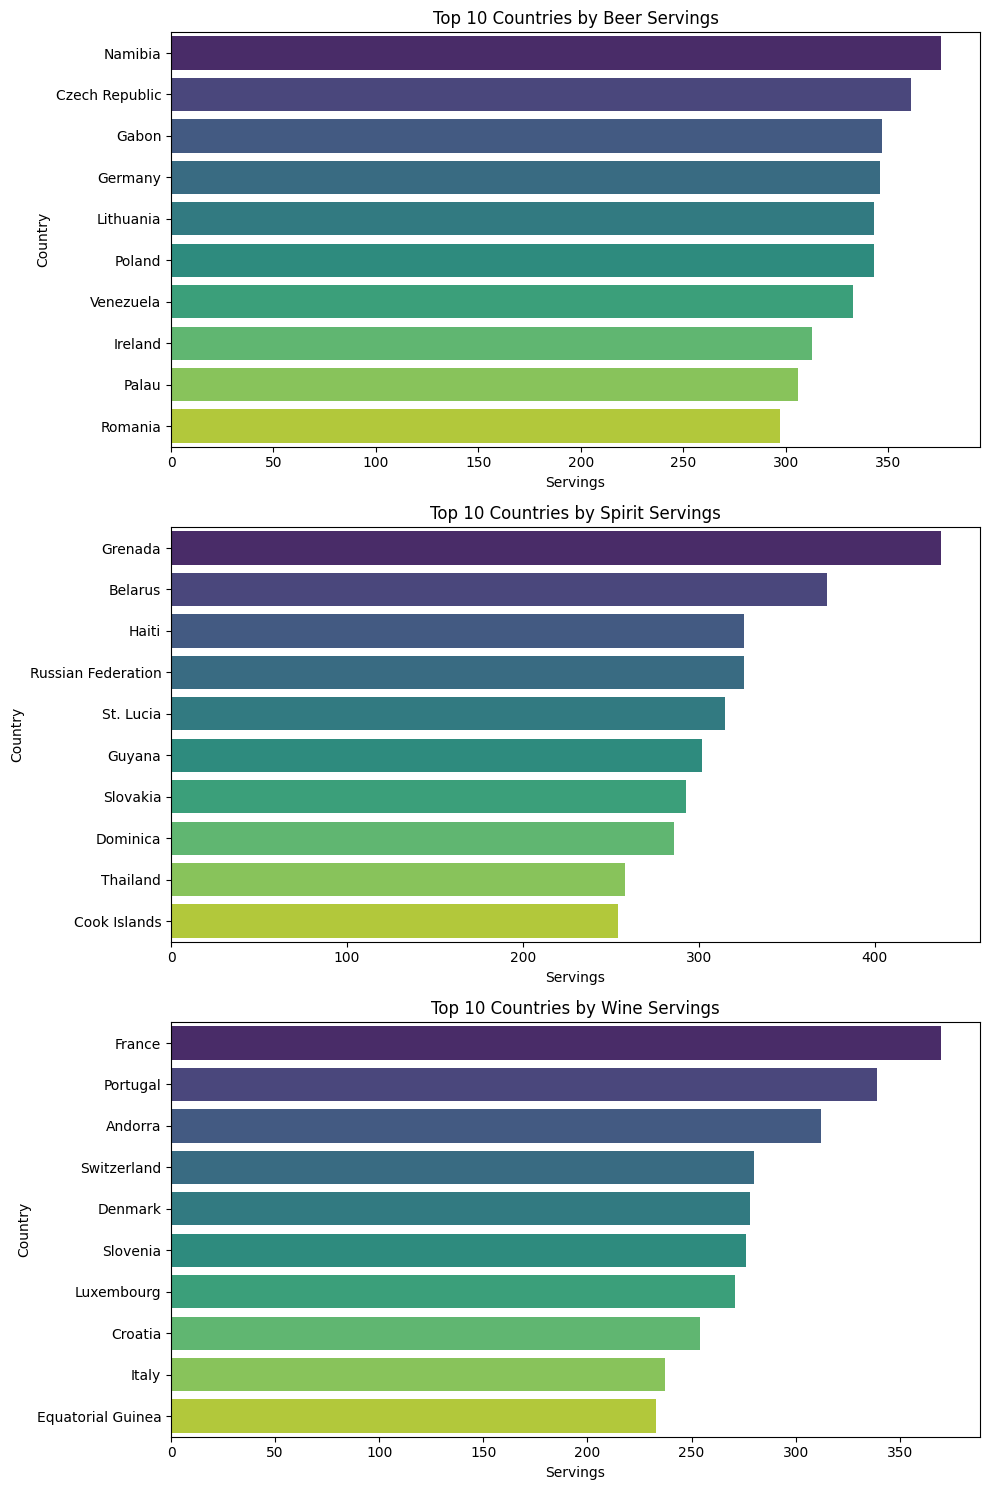

In [5]:
df_tidy['drink'] = df_tidy['drink'].str.replace('_servings', '', regex=False)

# Define categories
drink_types = ['beer', 'spirit', 'wine']

# Create plots
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

for i, drink in enumerate(drink_types):
    # Get top 10 for this drink type
    top_10 = df_tidy[df_tidy['drink'] == drink].nlargest(10, 'servings')

    sns.barplot(data=top_10, x='servings', y='country', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top 10 Countries by {drink.capitalize()} Servings')
    axes[i].set_xlabel('Servings')
    axes[i].set_ylabel('Country')

plt.tight_layout()
plt.show()

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [3]:
df_wide = df_tidy.pivot_table(index='country', columns='drink', values='servings').reset_index()

display(df_wide.head())

drink,country,beer,spirit,wine
0,Afghanistan,0.0,0.0,0.0
1,Albania,89.0,132.0,54.0
2,Algeria,25.0,0.0,14.0
3,Andorra,245.0,138.0,312.0
4,Angola,217.0,57.0,45.0
